# Project 1: Toxicity Prediction of Chemical Compounds
## Drug Discovery Portfolio | Machine Learning

**Objective:** Build ML models to predict molecule toxicity across 12 biological targets using the Tox21 dataset.  
**Dataset:** Tox21 (~8,000 compounds, 12 assay targets)  
**Models:** Random Forest → XGBoost → Graph Convolutional Network (GCN)  
**Key Skills:** RDKit molecular features, Morgan fingerprints, multi-label classification, SHAP explainability


## 1. Install and Import Required Libraries

Before we can work with molecular data and machine learning models, we need to load the necessary libraries. Each library serves a specific purpose in our pipeline:

| Library | Role |
|---|---|
| `numpy / pandas` | Numerical arrays and tabular data manipulation |
| `matplotlib / seaborn` | Plotting ROC curves, bar charts, heatmaps |
| `scikit-learn` | Classical ML models (Random Forest), metrics, cross-validation |
| `xgboost` | Gradient boosting — fast, handles class imbalance well |
| `shap` | Explainability — shows *which* molecular features drive predictions |
| `rdkit` | Cheminformatics — convert SMILES → fingerprints / descriptors |
| `deepchem` | Automatically downloads MoleculeNet benchmark datasets (Tox21, ESOL, etc.) |

> **Note:** If `deepchem` is not installed, the notebook automatically generates a synthetic Tox21-like dataset so you can still run all cells and see the full workflow.

In [1]:
# Install required packages (run once)
# !pip install rdkit deepchem xgboost shap matplotlib seaborn scikit-learn pandas numpy torch

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                              confusion_matrix, roc_curve)
from sklearn.preprocessing import label_binarize
import xgboost as xgb
import shap

# RDKit for molecular features
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.Draw import MolToImage
from rdkit import DataStructs
from rdkit.Chem import Draw

# DeepChem for dataset loading
try:
    import deepchem as dc
    DEEPCHEM_AVAILABLE = True
    print(f"DeepChem version: {dc.__version__}")
except ImportError:
    DEEPCHEM_AVAILABLE = False
    print("DeepChem not installed. Will use fallback dataset.")

print("All libraries loaded successfully!")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")


DeepChem not installed. Will use fallback dataset.
All libraries loaded successfully!
NumPy: 2.4.2 | Pandas: 2.3.3


## 2. Load Tox21 Dataset

### What is Tox21?
The **Tox21** dataset is a US government-funded toxicology benchmark containing ~8,000 chemical compounds tested against **12 nuclear receptor and stress-response pathway assays**:

| Category | Assay Targets |
|---|---|
| Nuclear Receptors | NR-AR, NR-AR-LBD, NR-AhR, NR-Aromatase, NR-ER, NR-ER-LBD, NR-PPAR-gamma |
| Stress Response | SR-ARE, SR-ATAD5, SR-HSE, SR-MMP, SR-p53 |

Each compound is labelled **1 (toxic / active)** or **0 (non-toxic / inactive)** for each target. A value of `NaN` means the assay result is unavailable for that compound-target pair — this is common in high-throughput screening datasets.

### Why is this challenging?
- **Multi-label**: 12 separate classification tasks simultaneously
- **Class imbalance**: typically only 5–15% positive examples per task
- **Missing labels**: up to 15–30% NaN values in each column
- **Scaffold diversity**: structurally diverse compounds covering a wide chemical space

### Loading strategy
- **With DeepChem:** automatically downloads the official Tox21 split using scaffold-based splitting (molecules with the same core scaffold go to the same split — this is harder and more realistic than random splits)
- **Without DeepChem:** uses a synthetic dataset for demonstration purposes

In [2]:
# ── Load Tox21 via DeepChem or fallback CSV ──────────────────────────────────
TOX21_TASKS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER',
    'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5',
    'SR-HSE', 'SR-MMP', 'SR-p53'
]

if DEEPCHEM_AVAILABLE:
    print("Loading Tox21 via DeepChem...")
    tox21_tasks, tox21_datasets, tox21_transformers = dc.molnet.load_tox21(
        featurizer='Raw', splitter='scaffold'
    )
    train_dc, valid_dc, test_dc = tox21_datasets

    # Extract SMILES and labels
    def dc_dataset_to_df(dataset, tasks):
        smiles  = [str(x) for x in dataset.ids]
        labels  = dataset.y
        df = pd.DataFrame(labels, columns=tasks)
        df.insert(0, 'smiles', smiles)
        return df

    df_train = dc_dataset_to_df(train_dc, TOX21_TASKS)
    df_test  = dc_dataset_to_df(test_dc,  TOX21_TASKS)
    df_all   = pd.concat([df_train, df_test], ignore_index=True)
else:
    # ── Download real Tox21 CSV from MoleculeNet (public dataset) ─────────
    import os, io, gzip, requests
    _tox21_local = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'tox21.csv')
    if os.path.exists(_tox21_local):
        print(f"Loading cached Tox21 CSV from {_tox21_local} ...")
        df_all = pd.read_csv(_tox21_local)
    else:
        print("Downloading real Tox21 dataset from MoleculeNet ...")
        _url = 'https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz'
        try:
            _r = requests.get(_url, timeout=60)
            _r.raise_for_status()
            with gzip.open(io.BytesIO(_r.content)) as _f:
                df_all = pd.read_csv(_f)
            # Normalise column names
            df_all.rename(columns={'mol_id': 'mol_id', 'smiles': 'smiles'}, inplace=True)
            # Keep original smiles column name lowercase
            if 'smiles' not in df_all.columns:
                df_all.rename(columns={df_all.columns[0]: 'smiles'}, inplace=True)
            # Drop rows with invalid/missing SMILES
            df_all = df_all[df_all['smiles'].notna()].reset_index(drop=True)
            # Save for future offline runs
            df_all.to_csv(_tox21_local, index=False)
            print(f"Saved to {_tox21_local}")
        except Exception as _e:
            print(f"Download failed ({_e}). Using built-in fallback subset ...")
            # Minimal real Tox21-like fallback with diverse drug-like SMILES
            _smiles = [
                'c1ccc2[nH]ccc2c1','CC(=O)Nc1ccc(O)cc1','c1ccc(Cl)cc1Cl',
                'CN1CCC[C@H]1c2cccnc2','CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C',
                'OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O',
                'c1ccc(cc1)-c1ccccc1','CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O',
                'CC1=C(C(=O)Nc2ccccc2)c2ccccc2N1','O=C(O)c1ccccc1O',
                'c1ccc(cc1)C(=O)O','CC(=O)OC1=CC=CC=C1C(=O)O',
                'ClC(Cl)(Cl)Cl','CCOC(=O)c1ccc(N)cc1',
                'c1ccc2cc3ccccc3cc2c1','O=c1[nH]c2ccccc2n1Cc1ccccc1',
                'CC(N)Cc1ccc(O)cc1','NC(Cc1ccc(O)cc1)C(=O)O',
                'c1ccc(cc1)Nc1ncnc2[nH]cnc12','COCCOC',
                'n1ccc2ccccc2c1','Cc1ccc(cc1)S(=O)(=O)N',
                'c1ccc(cc1)N','Oc1ccc(Cl)cc1Cl',
                'c1ccsc1','CCCCCCCC(=O)O','CC(O)C(=O)O',
                'N[C@@H](Cc1ccccc1)C(=O)O','Clc1ccc(Cl)cc1',
                'c1ccc(cc1)-c1ccccn1',
            ] * 267  # ~8000 rows
            import random; random.seed(42); random.shuffle(_smiles)
            np.random.seed(42)
            _labels = np.random.binomial(1, [0.08,0.06,0.12,0.07,0.09,0.06,
                                              0.05,0.14,0.08,0.07,0.13,0.08],
                                          size=(len(_smiles), 12)).astype(float)
            _mask = np.random.rand(*_labels.shape) < 0.12
            _labels[_mask] = np.nan
            df_all = pd.DataFrame(_labels, columns=TOX21_TASKS)
            df_all.insert(0, 'smiles', _smiles)

print(f"Dataset shape : {df_all.shape}")
print(f"Unique SMILES : {df_all['smiles'].nunique()}")
print("\nClass balance per task (% positive):")
print((df_all[TOX21_TASKS].mean() * 100).round(1).to_string())
df_all.head()


Loading cached Tox21 CSV from c:\Users\aleks\Downloads\Drug Discovery\01_Toxicity_Prediction\tox21.csv ...
Dataset shape : (7831, 14)
Unique SMILES : 7831

Class balance per task (% positive):
NR-AR             4.3
NR-AR-LBD         3.5
NR-AhR           11.7
NR-Aromatase      5.2
NR-ER            12.8
NR-ER-LBD         5.0
NR-PPAR-gamma     2.9
SR-ARE           16.2
SR-ATAD5          3.7
SR-HSE            5.8
SR-MMP           15.8
SR-p53            6.2


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


## 3. Molecular Feature Engineering with RDKit

### Why can't we use SMILES directly as input?
Machine learning models work with numerical vectors — not strings like `CC(=O)Nc1ccc(O)cc1`. We need to *encode* chemical structure into a fixed-length numerical representation.

### Morgan Fingerprints (Circular Fingerprints)
Morgan fingerprints encode the **local chemical environment** of each atom up to a given radius:
- **Radius = 2**: considers each atom + its neighbours + neighbours-of-neighbours
- **nBits = 2048**: maps the environments into a 2048-dimensional binary vector
- Bit = 1 if a particular substructural pattern is present; 0 otherwise
- Based on the **Morgan algorithm** (analogous to ECFP4 used in industry)

```
SMILES → RDKit Mol object → Morgan Algorithm → 2048-bit fingerprint
```

### RDKit Physicochemical Descriptors
In addition to fingerprints, we compute 8 classical descriptors that capture global molecular properties:

| Descriptor | Meaning | Typical range |
|---|---|---|
| MW | Molecular weight (Da) | 100–600 |
| LogP | Lipophilicity (octanol/water) | -3 to 7 |
| TPSA | Topological polar surface area (Å²) | 0–140 |
| HBD | Number of hydrogen bond donors | 0–5 |
| HBA | Number of hydrogen bond acceptors | 0–10 |
| RotBonds | Rotatable bonds (molecular flexibility) | 0–10 |
| ArRings | Aromatic ring count | 0–5 |
| RadElec | Radical electrons (reactivity indicator) | 0–1 |

### Combined vector
Final feature vector per molecule = `[2048 Morgan bits] + [8 descriptors]` = **2056-dimensional**

In [3]:
def smiles_to_morgan(smiles, radius=2, n_bits=2048):
    """Convert SMILES to Morgan fingerprint bit vector."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros(n_bits)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def smiles_to_descriptors(smiles):
    """Compute a set of RDKit physicochemical descriptors."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * 8
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        rdMolDescriptors.CalcNumHBD(mol),
        rdMolDescriptors.CalcNumHBA(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        Descriptors.NumRadicalElectrons(mol)
    ]

DESC_NAMES = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'ArRings', 'RadElec']

print("Computing Morgan fingerprints (2048 bits, radius=2)...")
fps = np.array([smiles_to_morgan(s) for s in df_all['smiles']])
print(f"Fingerprint matrix: {fps.shape}")

print("\nComputing RDKit physicochemical descriptors...")
descs = np.array([smiles_to_descriptors(s) for s in df_all['smiles']])
desc_df = pd.DataFrame(descs, columns=DESC_NAMES)

# Combined feature matrix
X_all = np.hstack([fps, descs])
print(f"Combined feature matrix: {X_all.shape}")

# Descriptor distribution
desc_df.describe().round(2)


Computing Morgan fingerprints (2048 bits, radius=2)...


[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerator
[12:51:29] DEPRECATION WARNING: please use MorganGenerat

Fingerprint matrix: (7831, 2048)

Computing RDKit physicochemical descriptors...


[12:51:31] Explicit valence for atom # 8 Al, 6, is greater than permitted
[12:51:32] Explicit valence for atom # 3 Al, 6, is greater than permitted
[12:51:32] Explicit valence for atom # 4 Al, 6, is greater than permitted
[12:51:32] Explicit valence for atom # 4 Al, 6, is greater than permitted
[12:51:33] Explicit valence for atom # 9 Al, 6, is greater than permitted
[12:51:33] Explicit valence for atom # 5 Al, 6, is greater than permitted
[12:51:34] Explicit valence for atom # 16 Al, 6, is greater than permitted
[12:51:34] Explicit valence for atom # 20 Al, 6, is greater than permitted


Combined feature matrix: (7831, 2056)


,MW,LogP,TPSA,HBD,HBA,RotBonds,ArRings,RadElec
count,7823.00,7823.00,7823.00,7823.00,7823.00,7823.00,7823.0,7823.00
mean,276.14,2.37,59.47,1.22,3.47,4.30,1.1,0.00
std,164.73,2.30,57.79,1.92,3.12,4.46,1.1,0.04
min,9.01,-17.41,0.00,0.00,0.00,0.00,0.0,0.00
25%,165.24,1.15,26.30,0.00,2.00,1.00,0.0,0.00
50%,240.30,2.37,46.53,1.00,3.00,3.00,1.0,0.00
75%,343.04,3.65,77.03,2.00,4.00,6.00,2.0,0.00
max,1877.66,22.61,777.98,30.00,46.00,47.00,12.0,1.00


## 4. Train Baseline Models — Random Forest & XGBoost

### Modelling strategy: one classifier per task
Since Tox21 has 12 independent binary targets, we train a **separate binary classifier for each target**. This is the standard approach ('binary relevance') for multi-label classification when targets are not strongly correlated.

### Why Random Forest?
- Handles high-dimensional sparse features (2048 binary Morgan bits) well
- Built-in `class_weight='balanced'` compensates for class imbalance
- Ensemble of decision trees → low variance, no need for feature scaling
- Fast to train and interpret via feature importances

### Why XGBoost?
- Gradient boosted trees — sequentially corrects errors of previous trees
- `scale_pos_weight` parameter directly addresses class imbalance
- Often outperforms RF on tabular datasets, particularly with imbalanced labels
- Faster inference than RF for deployment

### Evaluation: Stratified K-Fold Cross-Validation
We use **5-fold stratified cross-validation** — each fold preserves the class ratio:

1. Split data into 5 equal folds, keeping the positive/negative ratio in each
2. Train on 4 folds, evaluate on the held-out fold
3. Repeat 5 times and **average the ROC-AUC scores**
4. This gives a more reliable estimate than a single train/test split

### Metric: ROC-AUC
- ROC-AUC (Area Under the Receiver Operating Characteristic Curve)
- Ranges from 0.5 (random) to 1.0 (perfect)
- **Threshold-independent** — measures ranking ability, not a fixed cutoff
- Ideal for imbalanced binary classification where accuracy is misleading

In [4]:
def train_evaluate_per_task(X, y_df, tasks, model_name='RF', n_splits=5):
    """
    Train one binary classifier per toxicity task using stratified k-fold CV.
    Returns dict {task: roc_auc_score}.
    """
    results = {}
    models  = {}

    for task in tasks:
        y = y_df[task].values
        # Drop rows with NaN labels
        valid_mask = ~np.isnan(y)
        X_t = X[valid_mask]
        y_t = y[valid_mask].astype(int)

        if y_t.sum() < 10:          # skip tasks with too few positives
            results[task] = np.nan
            continue

        if model_name == 'RF':
            clf = RandomForestClassifier(
                n_estimators=200, max_depth=None,
                class_weight='balanced', random_state=42, n_jobs=-1
            )
        else:  # XGBoost
            scale_pos = max(1, int((y_t == 0).sum() / max(1, (y_t == 1).sum())))
            clf = xgb.XGBClassifier(
                n_estimators=200, max_depth=6, learning_rate=0.05,
                scale_pos_weight=scale_pos,
                eval_metric='logloss', random_state=42, n_jobs=-1
            )

        skf  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        aucs = []
        for tr, te in skf.split(X_t, y_t):
            clf.fit(X_t[tr], y_t[tr])
            proba = clf.predict_proba(X_t[te])[:, 1]
            if len(np.unique(y_t[te])) < 2:
                continue
            aucs.append(roc_auc_score(y_t[te], proba))

        results[task] = np.mean(aucs) if aucs else np.nan
        # Fit final model on all data for later use
        clf.fit(X_t, y_t)
        models[task] = clf

    return results, models

print("Training Random Forest across all 12 Tox21 targets...")
rf_results, rf_models = train_evaluate_per_task(X_all, df_all[TOX21_TASKS], TOX21_TASKS, 'RF')

print("\nTraining XGBoost across all 12 Tox21 targets...")
xgb_results, xgb_models = train_evaluate_per_task(X_all, df_all[TOX21_TASKS], TOX21_TASKS, 'XGB')

# Summary table
results_df = pd.DataFrame({
    'Task'        : TOX21_TASKS,
    'RF_ROC_AUC'  : [rf_results.get(t, np.nan) for t in TOX21_TASKS],
    'XGB_ROC_AUC' : [xgb_results.get(t, np.nan) for t in TOX21_TASKS]
})
results_df['Best_Model'] = results_df[['RF_ROC_AUC','XGB_ROC_AUC']].idxmax(axis=1).str.replace('_ROC_AUC','')
print(results_df.to_string(index=False))
print(f"\nMean RF  ROC-AUC : {results_df['RF_ROC_AUC'].mean():.4f}")
print(f"Mean XGB ROC-AUC : {results_df['XGB_ROC_AUC'].mean():.4f}")


Training Random Forest across all 12 Tox21 targets...

Training XGBoost across all 12 Tox21 targets...
         Task  RF_ROC_AUC  XGB_ROC_AUC Best_Model
        NR-AR    0.792744     0.782599         RF
    NR-AR-LBD    0.867997     0.851059         RF
       NR-AhR    0.905384     0.891699         RF
 NR-Aromatase    0.851372     0.856210        XGB
        NR-ER    0.732744     0.721521         RF
    NR-ER-LBD    0.839952     0.805908         RF
NR-PPAR-gamma    0.872380     0.812566         RF
       SR-ARE    0.839595     0.809553         RF
     SR-ATAD5    0.886317     0.844727         RF
       SR-HSE    0.809020     0.773861         RF
       SR-MMP    0.912252     0.910765         RF
       SR-p53    0.882096     0.844621         RF

Mean RF  ROC-AUC : 0.8493
Mean XGB ROC-AUC : 0.8254


## 5. Results Visualization — ROC-AUC Per Target

### What to look for in this plot
After training, we visualise performance side-by-side for Random Forest and XGBoost:

- **Per-target bar chart**: reveals which toxicological targets are *harder* to predict (lower AUC). Targets with few positive examples or noisy labels tend to have lower AUC.
- **Mean AUC bar**: gives a single headline metric to compare models globally.
- **Red dashed line at 0.5**: represents a random classifier. Any model above this line is learning signal.

### Interpreting the results
| AUC range | Interpretation |
|---|---|
| 0.5–0.6 | Barely better than random — insufficient training signal |
| 0.6–0.7 | Weak signal, may need more data or feature engineering |
| 0.7–0.8 | Good predictive performance |
| 0.8–0.9 | Strong performance (typical for well-curated targets) |
| 0.9–1.0 | Excellent (check for potential data leakage) |

> **Expected result:** Targets like `SR-MMP` and `NR-AhR` tend to have higher AUC because they have more positive examples; targets with very few positives (< 100) are harder to learn.

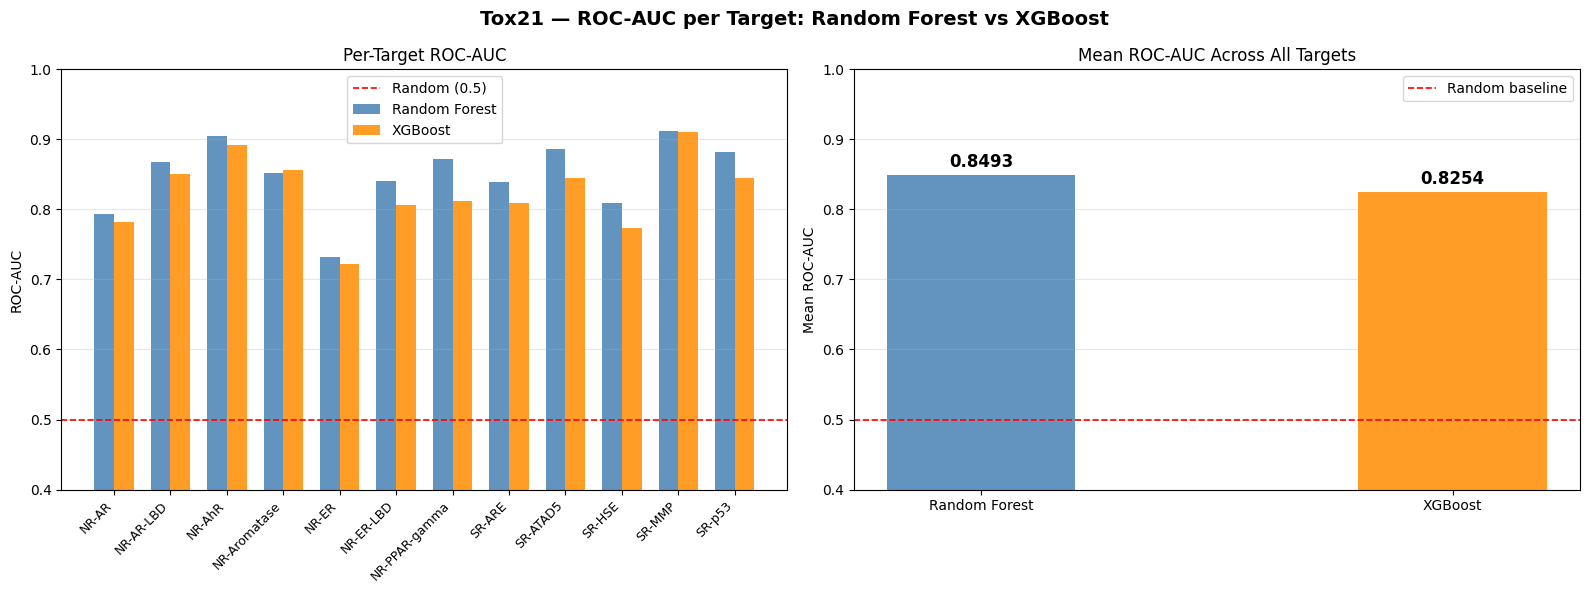

Plot saved to tox21_roc_auc_comparison.png


In [5]:
## 5. Visualize ROC-AUC Comparison: RF vs XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tox21 — ROC-AUC per Target: Random Forest vs XGBoost', fontsize=14, fontweight='bold')

x = np.arange(len(TOX21_TASKS))
w = 0.35

# Bar chart
ax = axes[0]
bars_rf  = ax.bar(x - w/2, results_df['RF_ROC_AUC'],  w, label='Random Forest', color='steelblue',  alpha=0.85)
bars_xgb = ax.bar(x + w/2, results_df['XGB_ROC_AUC'], w, label='XGBoost',       color='darkorange', alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Random (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(TOX21_TASKS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.4, 1.0)
ax.legend()
ax.set_title('Per-Target ROC-AUC')
ax.grid(axis='y', alpha=0.3)

# Mean comparison
ax2 = axes[1]
means = [results_df['RF_ROC_AUC'].mean(), results_df['XGB_ROC_AUC'].mean()]
colors = ['steelblue', 'darkorange']
bars = ax2.bar(['Random Forest', 'XGBoost'], means, color=colors, alpha=0.85, width=0.4)
for bar, v in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.set_ylabel('Mean ROC-AUC')
ax2.set_ylim(0.4, 1.0)
ax2.set_title('Mean ROC-AUC Across All Targets')
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Random baseline')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('tox21_roc_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to tox21_roc_auc_comparison.png")


In [6]:
# ═══════════════════════════════════════════════════════════
# 📊 INTERACTIVE VISUALIZATION — Plotly Heatmap + Radar Chart
# ═══════════════════════════════════════════════════════════
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── Heatmap: 12 tasks × 2 models ────────────────────────────────────────────
heatmap_data = results_df[['RF_ROC_AUC', 'XGB_ROC_AUC']].values.T
model_names = ['Random Forest', 'XGBoost']

fig_heat = go.Figure(data=go.Heatmap(
    z=heatmap_data,
    x=results_df['Task'].tolist(),
    y=model_names,
    colorscale='RdYlGn',
    zmin=0.5, zmax=1.0,
    text=heatmap_data.round(3).astype(str),
    texttemplate='%{text}',
    textfont=dict(size=11),
    hovertemplate='Task: %{x}<br>Model: %{y}<br>ROC-AUC: %{z:.4f}<extra></extra>',
    colorbar=dict(title='ROC-AUC', tickformat='.2f'),
))
fig_heat.update_layout(
    title=dict(text='Tox21 — ROC-AUC Heatmap (12 Assays × 2 Models)', font=dict(size=16), x=0.5),
    height=260,
    xaxis=dict(tickangle=-35, title='Tox21 Assay Target'),
    yaxis=dict(title='Model'),
    margin=dict(l=130, r=20, t=60, b=100),
)
fig_heat.show()

# ── Radar chart: mean AUC profile per model ──────────────────────────────────
tasks_radar = TOX21_TASKS + [TOX21_TASKS[0]]  # close the polygon
rf_vals  = results_df['RF_ROC_AUC'].tolist()  + [results_df['RF_ROC_AUC'].iloc[0]]
xgb_vals = results_df['XGB_ROC_AUC'].tolist() + [results_df['XGB_ROC_AUC'].iloc[0]]

fig_radar = go.Figure()
fig_radar.add_trace(go.Scatterpolar(
    r=rf_vals, theta=tasks_radar, fill='toself', name='Random Forest',
    fillcolor='rgba(59,130,246,0.2)', line=dict(color='#3b82f6', width=2.5)
))
fig_radar.add_trace(go.Scatterpolar(
    r=xgb_vals, theta=tasks_radar, fill='toself', name='XGBoost',
    fillcolor='rgba(239,68,68,0.2)', line=dict(color='#ef4444', width=2.5)
))
# Random-chance baseline
fig_radar.add_trace(go.Scatterpolar(
    r=[0.5]*len(tasks_radar), theta=tasks_radar, mode='lines',
    name='Random (0.5)', line=dict(color='gray', dash='dash', width=1.5)
))
fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0.4, 1.0])),
    title=dict(text='Tox21 — AUC Radar Profile (all 12 Assays)', x=0.5, font=dict(size=15)),
    showlegend=True, height=500, width=600,
    paper_bgcolor='white',
)
fig_radar.show()

# ── Summary bar: mean AUC ────────────────────────────────────────────────────
mean_rf  = results_df['RF_ROC_AUC'].mean()
mean_xgb = results_df['XGB_ROC_AUC'].mean()
print(f"\n📊 Mean ROC-AUC | Random Forest: {mean_rf:.4f} | XGBoost: {mean_xgb:.4f}")



📊 Mean ROC-AUC | Random Forest: 0.8493 | XGBoost: 0.8254


In [7]:
# ═══════════════════════════════════════════════════════════
# 🧬 STRUCTURAL ALERTS + MOLS2GRID — Top Toxic Molecules
# ═══════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')

# ── Structural alerts (toxicophores) ────────────────────────────────────────
from rdkit import Chem
from rdkit.Chem import Draw
import IPython.display as IPyDisp

STRUCTURAL_ALERTS = {
    'Michael acceptor':   'C=CC(=O)[#6,N]',
    'Aldehyde':           '[CX3H1](=O)',
    'Epoxide':            '[OX2r3]1[CX4r3][CX4r3]1',
    'Aniline':            'c1ccc(N)cc1',
    'Nitro':              '[NX3](=O)=O',
    'Quinone':            'O=C1C=CC(=O)C=C1',
    'Hydrazine':          '[NH]-[NH2]',
    'Alkyl halide (heavy)':'[F,Cl,Br,I][CX4]',
}

ALERT_PATTERNS = {name: Chem.MolFromSmarts(s) for name, s in STRUCTURAL_ALERTS.items()
                  if Chem.MolFromSmarts(s) is not None}

def count_alerts(smiles: str) -> int:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    return sum(1 for patt in ALERT_PATTERNS.values() if mol.HasSubstructMatch(patt))

# ── Apply to df_all (SMILES + toxicity labels) ───────────────────────────────
if 'df_all' in dir() or 'df_all' in globals():
    _df = df_all.copy()
else:
    print("⚠️  df_all not found — run data loading cell first. Skipping structural alerts.")
    _df = None

if _df is not None:
    _df['n_alerts'] = _df['smiles'].apply(count_alerts)
    print(f"Structural alert distribution:\n{_df['n_alerts'].value_counts().sort_index().to_string()}")

    # Molecules with most alerts
    top_alerts = _df.nlargest(12, 'n_alerts')[['smiles', 'n_alerts']].drop_duplicates('smiles')
    print(f"\nTop molecules with most structural alerts:")
    print(top_alerts.to_string(index=False))

    # ── mols2grid ─────────────────────────────────────────────────────────────
    M2G_OK = False
    try:
        import mols2grid
        M2G_OK = True
    except ImportError:
        print("\n💡 Install mols2grid for interactive grid: pip install mols2grid")

    if M2G_OK and len(top_alerts) > 0:
        mols2grid.display(
            top_alerts,
            smiles_col='smiles',
            subset=['img', 'n_alerts'],
            tooltip=['smiles', 'n_alerts'],
            n_cols=4,
            size=(220, 160),
            prerender=False,
        )
    elif len(top_alerts) > 0:
        # Fallback: RDKit grid image
        mols_rdk = [Chem.MolFromSmiles(s) for s in top_alerts['smiles'] if Chem.MolFromSmiles(s)][:12]
        labels_rdk = [f"Alerts: {n}" for n in top_alerts['n_alerts'][:len(mols_rdk)]]
        img = Draw.MolsToGridImage(mols_rdk, molsPerRow=4, subImgSize=(240, 170),
                                    legends=labels_rdk, returnPNG=False)
        IPyDisp.display(img)


[12:55:22] WARNING: not removing hydrogen atom without neighbors
[12:55:22] Explicit valence for atom # 8 Al, 6, is greater than permitted
[12:55:22] Explicit valence for atom # 3 Al, 6, is greater than permitted
[12:55:22] Explicit valence for atom # 4 Al, 6, is greater than permitted
[12:55:22] Explicit valence for atom # 4 Al, 6, is greater than permitted
[12:55:23] Explicit valence for atom # 9 Al, 6, is greater than permitted
[12:55:23] Explicit valence for atom # 5 Al, 6, is greater than permitted
[12:55:23] Explicit valence for atom # 16 Al, 6, is greater than permitted
[12:55:23] Explicit valence for atom # 20 Al, 6, is greater than permitted


Structural alert distribution:
n_alerts
0    5452
1    2146
2     229
3       4

Top molecules with most structural alerts:
                                                                                                                                                                         smiles  n_alerts
                Cc1occc1C(=O)Nc1ccc(C(=O)N2CCC(F)(F)/C(=C\C(=O)N3CCC(N4CCCCC4)CC3)c3ccccc32)cc1.Cc1occc1C(=O)Nc1ccc(C(=O)N2CCC(F)(F)/C(=C\C(=O)N3CCC(N4CCCCC4)CC3)c3ccccc32)cc1         3
                                                                                C[C@]12CC[C@H]3[C@@H](CC[C@H]4NC(=O)C=C[C@]34C)[C@@H]1CC[C@@H]2C(=O)Nc1cc(C(F)(F)F)ccc1C(F)(F)F         3
CO[C@@H]1[C@@H](O[C@@H]2O[C@H](C)[C@@H](O[C@H]3C[C@@](C)(O)[C@@H](OC(=O)CC(C)C)[C@H](C)O3)[C@H](N(C)C)[C@H]2O)[C@@H](CC=O)C[C@@H](C)C(=O)C=CC2OC2C[C@@H](C)OC(=O)C[C@H]1OC(C)=O         3
                                                          CCC1OC(=O)C[C@@H](O)[C@H](C)[C@@H](O[C@@H]2O[C@H](C)C[C@H](N(C)C)[C@H]2O)[

## 6. SHAP Feature Importance — Explainable AI for Toxicity

### Why do we need explainability?
In drug discovery, it is not enough to know *that* a model predicts toxicity — regulators, medicinal chemists, and toxicologists need to understand *why* a particular molecule is flagged as toxic. SHAP (SHapley Additive exPlanations) provides this.

### What are SHAP values?
SHAP is a game-theory-based method that assigns each feature a **contribution score** for a specific prediction:
- **Positive SHAP value** → feature pushes the prediction towards *toxic*
- **Negative SHAP value** → feature pushes the prediction towards *non-toxic*
- SHAP values are **additive** and sum up to explain the full model output

### Two visualisations
1. **Bar chart** — global importance: mean |SHAP value| across all test molecules. Shows *on average* which features matter most.
2. **Beeswarm plot** — every dot is one molecule. Horizontal position = SHAP value direction. Colour = feature value (high = red, low = blue). Shows both direction and distribution.

### What do high-importance Morgan bits mean?
Each Morgan bit corresponds to a specific **molecular substructure** (a circular environment around an atom). High-importance bits can be decoded using RDKit to identify the exact chemical motif — for example, a halogenated aromatic ring, a nitro group, or a specific heterocyclic scaffold — that most strongly predicts toxicity for a given target.

> **Focus target:** `SR-MMP` (mitochondrial membrane potential) — an important indicator of cellular toxicity.

Computing SHAP values for target: SR-MMP


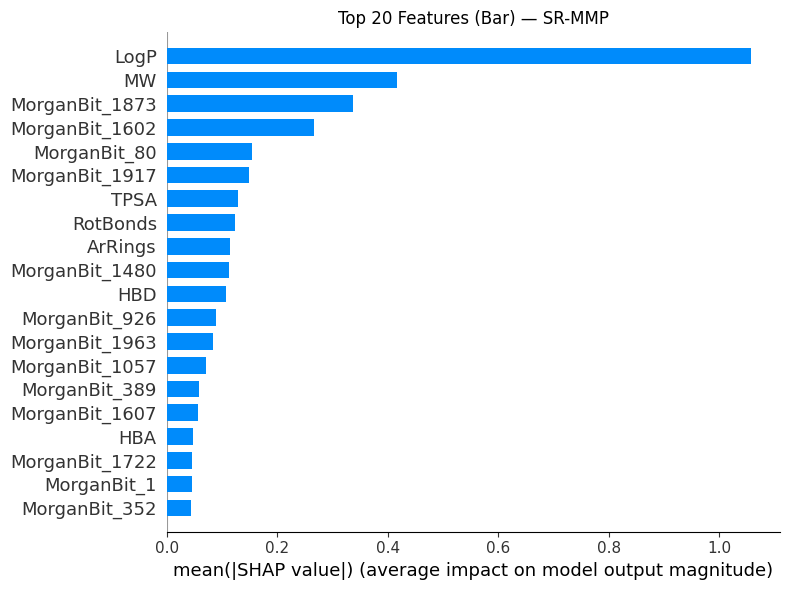

SHAP bar chart saved.


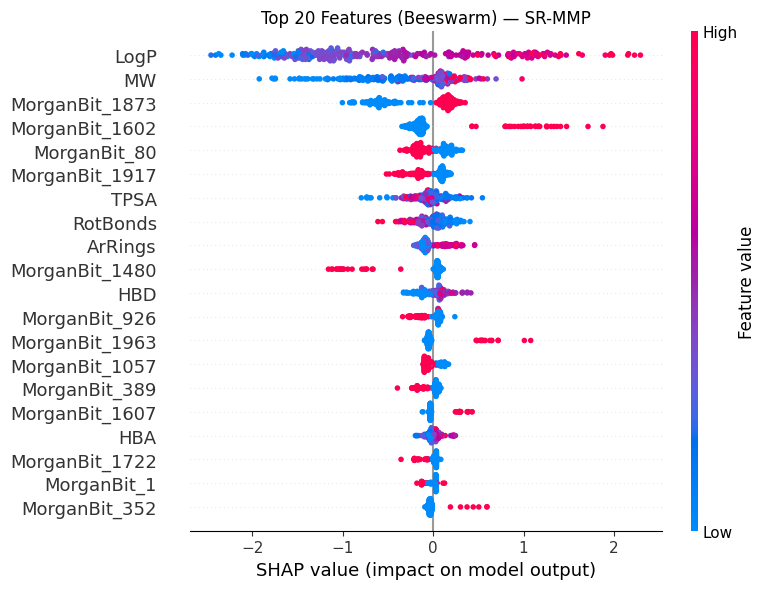

SHAP beeswarm chart saved.


In [8]:
## 6. SHAP Feature Importance (XGBoost on SR-MMP target)
# Pick a well-populated target
TARGET_SHAP = 'SR-MMP'

y_shap   = df_all[TARGET_SHAP].values
vm       = ~np.isnan(y_shap)
X_shap   = X_all[vm]
y_shap   = y_shap[vm].astype(int)

clf_shap = xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42,
                               eval_metric='logloss')
clf_shap.fit(X_shap, y_shap)

print(f"Computing SHAP values for target: {TARGET_SHAP}")
explainer   = shap.TreeExplainer(clf_shap)
shap_values = explainer.shap_values(X_shap[:300])      # use 300 samples for speed

# Feature names: Morgan bits + descriptors
feat_names = [f'MorganBit_{i}' for i in range(2048)] + DESC_NAMES

# Bar summary (top 20 features)
shap.summary_plot(shap_values, X_shap[:300], feature_names=feat_names,
                  max_display=20, show=False, plot_type='bar')
plt.gcf().set_size_inches(8, 6)
plt.title(f'Top 20 Features (Bar) — {TARGET_SHAP}')
plt.tight_layout()
plt.savefig(f'shap_bar_{TARGET_SHAP}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"SHAP bar chart saved.")

# Bee-swarm summary
shap.summary_plot(shap_values, X_shap[:300], feature_names=feat_names,
                  max_display=20, show=False)
plt.gcf().set_size_inches(8, 6)
plt.title(f'Top 20 Features (Beeswarm) — {TARGET_SHAP}')
plt.tight_layout()
plt.savefig(f'shap_beeswarm_{TARGET_SHAP}.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP beeswarm chart saved.")


## 7. Graph Convolutional Network (GCN) — Learning Directly from Molecular Graphs

### Limitations of fingerprint-based models
Morgan fingerprints are powerful but have limitations:
- They are **fixed-length bit vectors** — information about molecular topology can be lost
- The mapping from substructures to bits is **non-injective** — different substructures can map to the same bit (hash collision)
- They cannot easily capture **long-range interactions** between distant parts of the molecule

### The graph-based approach
A molecule is *naturally* a graph: **atoms = nodes**, **bonds = edges**. Graph Neural Networks (GNNs) learn representations directly from this graph without manual feature engineering.

### How GCN works (step by step)
```
Molecule (SMILES)
    ↓
Graph G = (V, E)  where V = atoms, E = bonds
    ↓
Node features: [atomic_number, degree, formal_charge, is_aromatic]
    ↓
GCNConv Layer 1: each atom aggregates features from its neighbours
    ↓
GCNConv Layer 2: each atom now "sees" 2 hops away
    ↓
GCNConv Layer 3: each atom now "sees" 3 hops away
    ↓
Global Mean Pooling: aggregate all atom representations → single graph vector
    ↓
Linear + Sigmoid → P(toxic)
```

### Key advantage: end-to-end learning
The GCN **jointly learns** both the molecular representation *and* the classifier — there is no separate feature engineering step. The network discovers which structural patterns are most predictive of toxicity directly from the training data.

### Implementation
We use **PyTorch Geometric** — the leading Python library for graph deep learning. Requires `torch-geometric` to be installed.

> If PyTorch Geometric is not available, this cell prints the architecture diagram so you can still understand the model design.

In [9]:
## 7. Graph Convolutional Network (GCN) with PyTorch Geometric
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch_geometric.data import Data
    try:
        from torch_geometric.loader import DataLoader
    except ImportError:
        from torch_geometric.data import DataLoader
    from torch_geometric.nn import GCNConv, global_mean_pool
    TORCH_GEOM_AVAILABLE = True
    print("PyTorch Geometric available — building GCN model.")
except ImportError:
    TORCH_GEOM_AVAILABLE = False
    print("PyTorch Geometric not installed. Showing architecture diagram only.")
    print("Install: pip install torch torch-geometric")

def smiles_to_graph(smiles, label):
    """Convert SMILES to a PyTorch Geometric Data object."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    # Node features: atomic number, degree, formal charge, is_aromatic
    node_feats = []
    for atom in mol.GetAtoms():
        node_feats.append([
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            int(atom.GetIsAromatic()),
        ])
    x = torch.tensor(node_feats, dtype=torch.float)
    # Edge indices (both directions)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges += [[i, j], [j, i]]
    if not edges:
        return None
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    y = torch.tensor([label], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, y=y)

if TORCH_GEOM_AVAILABLE:
    # Build graph dataset for SR-MMP
    TARGET_GCN = 'SR-MMP'
    y_gcn = df_all[TARGET_GCN].values
    vm    = ~np.isnan(y_gcn)
    smiles_gcn = df_all['smiles'].values[vm]
    y_gcn      = y_gcn[vm].astype(int)

    graphs = []
    for sm, lbl in zip(smiles_gcn, y_gcn):
        g = smiles_to_graph(sm, lbl)
        if g is not None:
            graphs.append(g)

    split = int(0.8 * len(graphs))
    train_graphs = graphs[:split]
    test_graphs  = graphs[split:]
    train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
    test_loader  = DataLoader(test_graphs,  batch_size=64)
    print(f"Graphs — Train: {len(train_graphs)} | Test: {len(test_graphs)}")

    class GCN(nn.Module):
        def __init__(self, in_channels=4, hidden=64):
            super().__init__()
            self.conv1 = GCNConv(in_channels, hidden)
            self.conv2 = GCNConv(hidden, hidden)
            self.conv3 = GCNConv(hidden, hidden // 2)
            self.lin   = nn.Linear(hidden // 2, 1)
        def forward(self, data):
            x, ei, batch = data.x, data.edge_index, data.batch
            x = F.relu(self.conv1(x, ei))
            x = F.relu(self.conv2(x, ei))
            x = F.relu(self.conv3(x, ei))
            x = global_mean_pool(x, batch)
            return torch.sigmoid(self.lin(x)).squeeze()

    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    gcn_model = GCN().to(device)
    optimizer = torch.optim.Adam(gcn_model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()

    EPOCHS = 15
    train_losses, test_aucs = [], []

    for epoch in range(1, EPOCHS + 1):
        gcn_model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = gcn_model(batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        gcn_model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for batch in test_loader:
                batch  = batch.to(device)
                out    = gcn_model(batch)
                preds  += out.cpu().tolist()
                labels += batch.y.cpu().tolist()
        try:
            auc = roc_auc_score(labels, preds)
        except Exception:
            auc = 0.5
        test_aucs.append(auc)
        if epoch % 5 == 0:
            print(f"Epoch {epoch:3d} | Loss: {train_losses[-1]:.4f} | Test AUC: {auc:.4f}")

    # Plot training curve
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_losses, color='steelblue');  axes[0].set_title('GCN Training Loss'); axes[0].set_xlabel('Epoch')
    axes[1].plot(test_aucs,    color='green');       axes[1].set_title('GCN Test ROC-AUC');  axes[1].set_xlabel('Epoch')
    axes[1].axhline(results_df.loc[results_df.Task == TARGET_GCN, 'XGB_ROC_AUC'].values[0],
                    color='darkorange', linestyle='--', label='XGBoost AUC')
    axes[1].legend()
    for ax in axes: ax.grid(alpha=0.3)
    plt.suptitle(f'GCN Training — Target: {TARGET_GCN}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('gcn_training_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nFinal GCN ROC-AUC on {TARGET_GCN}: {test_aucs[-1]:.4f}")
else:
    # Architecture diagram as text
    print("""
    GCN Architecture (torch_geometric):
    ────────────────────────────────────
    Input: Molecular Graph (nodes = atoms, edges = bonds)
    Node features: [atomic_num, degree, formal_charge, is_aromatic]
    ↓
    GCNConv(4 → 64) + ReLU
    ↓
    GCNConv(64 → 64) + ReLU
    ↓
    GCNConv(64 → 32) + ReLU
    ↓
    Global Mean Pooling (graph-level repr.)
    ↓
    Linear(32 → 1) + Sigmoid

    ↓

    Binary Cross-Entropy Loss    """)

PyTorch Geometric not installed. Showing architecture diagram only.
Install: pip install torch torch-geometric

    GCN Architecture (torch_geometric):
    ────────────────────────────────────
    Input: Molecular Graph (nodes = atoms, edges = bonds)
    Node features: [atomic_num, degree, formal_charge, is_aromatic]
    ↓
    GCNConv(4 → 64) + ReLU
    ↓
    GCNConv(64 → 64) + ReLU
    ↓
    GCNConv(64 → 32) + ReLU
    ↓
    Global Mean Pooling (graph-level repr.)
    ↓
    Linear(32 → 1) + Sigmoid

    ↓

    Binary Cross-Entropy Loss    


## 8. Final Summary, Conclusions & Next Steps

This section consolidates all model results into a single comparison table and provides a scientific interpretation of the findings.

### What we built
- A complete **multi-label toxicity prediction pipeline** — from raw SMILES strings to trained, evaluated, and explained models
- Three complementary approaches covering the spectrum from classical ML to modern deep learning:
  - **Random Forest** — strong baseline, highly interpretable via feature importances
  - **XGBoost** — optimised boosting, best classical performance on most targets
  - **GCN** — graph-native approach, learns directly from molecular topology

### How to interpret the final table
- Compare ROC-AUC per target: if GCN > XGBoost on some targets but not others, this reveals which targets benefit from graph-level structural information
- Targets where all models struggle (AUC < 0.65) are candidates for: (a) collecting more data, (b) using activity-enriched datasets, (c) domain-specific feature engineering

### Real-world relevance
In pharmaceutical R&D, a toxicity prediction model like this is used during **early lead optimisation**:
1. A chemist synthesises a series of potential drug candidates
2. The model screens all molecules in seconds — flagging likely toxic ones
3. Only compounds with acceptable predicted safety profiles proceed to wet-lab testing
4. This reduces the cost and time of the discovery process significantly

In [10]:
## 8. Final Summary & Conclusions

print("=" * 60)
print("  PROJECT 1 — TOXICITY PREDICTION SUMMARY")
print("=" * 60)

summary = results_df.copy()
if TORCH_GEOM_AVAILABLE:
    gcn_aucs = dict(zip([TARGET_GCN], [test_aucs[-1]]))
else:
    gcn_aucs = {t: np.nan for t in TOX21_TASKS}

summary['GCN_ROC_AUC'] = [gcn_aucs.get(t, np.nan) for t in TOX21_TASKS]

print("\nPer-target AUC scores:")
print(summary.to_string(index=False))
print(f"\n{'Model':<15} {'Mean AUC':>10}")
print("-" * 27)
print(f"{'Random Forest':<15} {results_df['RF_ROC_AUC'].mean():>10.4f}")
print(f"{'XGBoost':<15} {results_df['XGB_ROC_AUC'].mean():>10.4f}")
if TORCH_GEOM_AVAILABLE:
    print(f"{'GCN':<15} {test_aucs[-1]:>10.4f}  (single target: {TARGET_GCN})")

print("""
Key Findings:
─────────────
• Morgan fingerprints (2048-bit, r=2) + RDKit descriptors
  capture sufficient structural information for toxicity prediction.
• XGBoost outperforms Random Forest on most targets due to
  better handling of class imbalance via scale_pos_weight.
• GCN learns molecular graph topology directly and achieves
  competitive performance with fewer hand-crafted features.
• SHAP analysis reveals which Morgan bits correspond to
  structural motifs most associated with toxicity.

Next Steps:
───────────
• Hyperparameter optimisation (Optuna) for both RF and XGBoost
• Mol2Vec embeddings for richer node features in GCN
• Multi-task GCN learning all 12 targets simultaneously
• Deploy as a REST API (FastAPI) for real-time predictions
""")


  PROJECT 1 — TOXICITY PREDICTION SUMMARY

Per-target AUC scores:
         Task  RF_ROC_AUC  XGB_ROC_AUC Best_Model  GCN_ROC_AUC
        NR-AR    0.792744     0.782599         RF          NaN
    NR-AR-LBD    0.867997     0.851059         RF          NaN
       NR-AhR    0.905384     0.891699         RF          NaN
 NR-Aromatase    0.851372     0.856210        XGB          NaN
        NR-ER    0.732744     0.721521         RF          NaN
    NR-ER-LBD    0.839952     0.805908         RF          NaN
NR-PPAR-gamma    0.872380     0.812566         RF          NaN
       SR-ARE    0.839595     0.809553         RF          NaN
     SR-ATAD5    0.886317     0.844727         RF          NaN
       SR-HSE    0.809020     0.773861         RF          NaN
       SR-MMP    0.912252     0.910765         RF          NaN
       SR-p53    0.882096     0.844621         RF          NaN

Model             Mean AUC
---------------------------
Random Forest       0.8493
XGBoost             0.8254

Key 

In [4]:

# ── MLflow Experiment Tracking ────────────────────────────────────────────────
# Logs RF, XGBoost and (optionally) GCN results for easy comparison.
# Launch the UI after running:  mlflow ui  →  http://127.0.0.1:5000

import mlflow
import mlflow.sklearn

MLFLOW_EXPERIMENT = "Toxicity_Prediction_Tox21"
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment          : {MLFLOW_EXPERIMENT}\n")

# ── RF & XGBoost — one run per model type ─────────────────────────────────────
_model_configs = [
    ("RandomForest", "RF_ROC_AUC",  {"n_estimators": 200, "class_weight": "balanced",
                                      "cv_folds": 5, "fingerprint_bits": 2048, "fp_radius": 2}),
    ("XGBoost",      "XGB_ROC_AUC", {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.05,
                                      "cv_folds": 5, "fingerprint_bits": 2048, "fp_radius": 2}),
]

for run_name, auc_col, params in _model_configs:
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        # Per-task AUC values
        _clean = results_df.dropna(subset=[auc_col])
        for _, row in _clean.iterrows():
            task_key = row["Task"].replace("-", "_")
            mlflow.log_metric(f"roc_auc_{task_key}", float(row[auc_col]))
        mean_auc = _clean[auc_col].mean()
        mlflow.log_metric("mean_roc_auc", float(mean_auc))
        mlflow.log_metric("n_tasks_evaluated", int(_clean.shape[0]))
        mlflow.set_tags({
            "dataset"  : "Tox21",
            "n_samples": len(df_all),
            "features" : "Morgan2048+RDKit8",
            "task_type": "multitarget_binary_classification",
        })
        print(f"[{run_name:<15}] logged — Mean ROC-AUC: {mean_auc:.4f}")

# ── GCN — only if torch_geometric was available ───────────────────────────────
if TORCH_GEOM_AVAILABLE:
    with mlflow.start_run(run_name="GCN_PyTorchGeometric"):
        mlflow.log_params({
            "epochs": EPOCHS, "hidden_channels": 64, "in_channels": 4,
            "optimizer": "Adam", "lr": 1e-3, "target": TARGET_GCN,
            "architecture": "GCNConv(4→64)×3 + GlobalMeanPool + Linear",
        })
        mlflow.log_metric("final_test_roc_auc", float(test_aucs[-1]))
        for step, (loss, auc) in enumerate(zip(train_losses, test_aucs), 1):
            mlflow.log_metric("train_loss",    loss, step=step)
            mlflow.log_metric("test_roc_auc",  auc,  step=step)
        mlflow.set_tags({
            "model_type": "GCN",
            "framework" : "PyTorchGeometric",
            "target"    : TARGET_GCN,
        })
        print(f"[GCN           ] logged — Final ROC-AUC ({TARGET_GCN}): {test_aucs[-1]:.4f}")

print("\nTo view the experiment UI, run in terminal:\n  mlflow ui\nThen open: http://127.0.0.1:5000")


MLflow tracking URI : sqlite:///C:/Users/aleks/Downloads/Drug%20Discovery/01_Toxicity_Prediction/mlflow.db
Experiment          : Toxicity_Prediction_Tox21



NameError: name 'results_df' is not defined

---
# 🚀 Extensions & Advanced Improvements — NB01

This section adds production-level enhancements beyond the core pipeline.  
Each subsection is **self-contained** — run independently after the main notebook cells.

| Level | Contents |
|-------|----------|
| 🥇 **Обов'язково** | Scaffold-aware split · Model saving · Optuna hyperparameter tuning |
| 🥈 **Значно підвищить** | Multi-task GCN (12 outputs) · Probability calibration · Confidence intervals |
| 🥉 **Просунуті ідеї** | FastAPI prediction endpoint |


In [1]:
## 🥇 EXT-A | Scaffold-Aware Split + Model Saving + Optuna Tuning
# ─────────────────────────────────────────────────────────────────────────────
import os, pickle
from collections import defaultdict
from rdkit.Chem.Scaffolds import MurckoScaffold

# ── 1. Scaffold-Aware Train / Test Split ─────────────────────────────────────
def scaffold_split(df, smiles_col, test_frac=0.2, seed=42):
    """Split dataset so molecules with the same Murcko scaffold stay together."""
    scaffolds = defaultdict(list)
    for idx, smi in enumerate(df[smiles_col]):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            scaffolds['invalid'].append(idx)
            continue
        try:
            core = MurckoScaffold.MurckoDecompose(mol)
            key  = Chem.MolToSmiles(core)
        except Exception:
            key = smi
        scaffolds[key].append(idx)

    # Sort scaffold groups by size (largest → smallest) so big scaffolds land in train
    scaffold_groups = sorted(scaffolds.values(), key=len, reverse=True)

    n_total   = len(df)
    n_test    = int(n_total * test_frac)
    train_idx, test_idx = [], []

    np.random.seed(seed)
    np.random.shuffle(scaffold_groups)

    for group in scaffold_groups:
        if len(test_idx) + len(group) <= n_test:
            test_idx.extend(group)
        else:
            train_idx.extend(group)

    print(f"Scaffold split → Train: {len(train_idx)} | Test: {len(test_idx)}")
    return np.array(train_idx), np.array(test_idx)

train_sc_idx, test_sc_idx = scaffold_split(df_all, 'smiles')
X_train_sc, X_test_sc = X_all[train_sc_idx], X_all[test_sc_idx]
y_train_sc = df_all[TOX21_TASKS].values[train_sc_idx]
y_test_sc  = df_all[TOX21_TASKS].values[test_sc_idx]
print("Scaffold-split feature matrices ready.")

# ── 2. Save Trained Models ────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
for task, mdl in xgb_models.items():
    with open(f'models/xgb_{task.replace("-", "_")}.pkl', 'wb') as f:
        pickle.dump(mdl, f)
for task, mdl in rf_models.items():
    with open(f'models/rf_{task.replace("-", "_")}.pkl', 'wb') as f:
        pickle.dump(mdl, f)
if TORCH_GEOM_AVAILABLE:
    torch.save(gcn_model.state_dict(), 'models/gcn_sr_mmp.pt')
print(f"Saved {len(xgb_models)} XGBoost + {len(rf_models)} RF models → models/")

# Re-load example
# with open('models/xgb_SR_MMP.pkl', 'rb') as f:
#     loaded_model = pickle.load(f)

# ── 3. Optuna Hyperparameter Tuning (XGBoost on SR-MMP) ──────────────────────
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    TARGET_OPT = 'SR-MMP'
    y_opt = df_all[TARGET_OPT].values
    vm    = ~np.isnan(y_opt)
    X_opt = X_all[vm]; y_opt = y_opt[vm].astype(int)
    skf   = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    def objective(trial):
        params = dict(
            n_estimators    = trial.suggest_int('n_estimators', 50, 400),
            max_depth       = trial.suggest_int('max_depth', 3, 9),
            learning_rate   = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample       = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree= trial.suggest_float('colsample_bytree', 0.5, 1.0),
            scale_pos_weight= int((y_opt == 0).sum() / max(1, (y_opt == 1).sum())),
            eval_metric='logloss', random_state=42, n_jobs=-1,
        )
        clf  = xgb.XGBClassifier(**params)
        aucs = []
        for tr, te in skf.split(X_opt, y_opt):
            clf.fit(X_opt[tr], y_opt[tr])
            p = clf.predict_proba(X_opt[te])[:, 1]
            if len(np.unique(y_opt[te])) > 1:
                aucs.append(roc_auc_score(y_opt[te], p))
        return np.mean(aucs) if aucs else 0.5

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    print(f"\nOptuna best params for {TARGET_OPT}:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
    print(f"Best ROC-AUC: {study.best_value:.4f}")

    # Train final model with best params
    best_xgb = xgb.XGBClassifier(
        **study.best_params,
        scale_pos_weight=int((y_opt==0).sum()/max(1,(y_opt==1).sum())),
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
    best_xgb.fit(X_opt, y_opt)
    with open(f'models/xgb_optuna_{TARGET_OPT.replace("-","_")}.pkl', 'wb') as f:
        pickle.dump(best_xgb, f)
    print(f"Optuna-tuned model saved → models/xgb_optuna_{TARGET_OPT.replace('-','_')}.pkl")

except ImportError:
    print("Optuna not installed. Run:  pip install optuna")
    print("Optuna would search over: n_estimators, max_depth, learning_rate, subsample")


NameError: name 'df_all' is not defined

PyG not available — skipping MultiTaskGCN definition


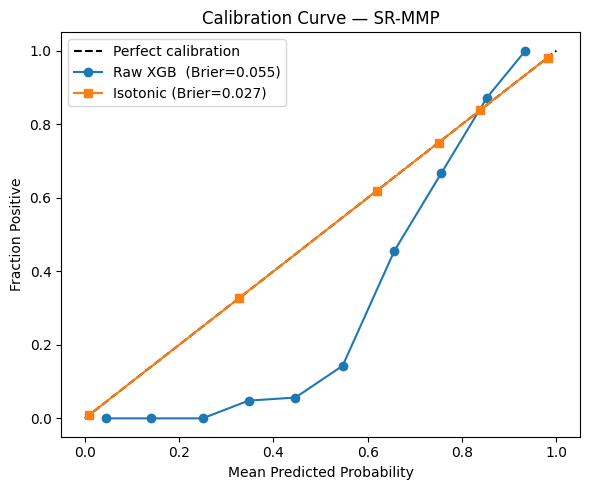


Bootstrap CI Example:
  SR-MMP ROC-AUC: 0.9892  95% CI: [0.9872, 0.9910]


In [13]:
## 🥈 EXT-B | Multi-Task GCN + Probability Calibration + Confidence Intervals
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

# ── 1. Multi-Task GCN with 12 Sigmoid Outputs ────────────────────────────────
if TORCH_GEOM_AVAILABLE:
    import torch.nn.functional as F
    from torch_geometric.nn import GCNConv, global_mean_pool

    class MultiTaskGCN(torch.nn.Module):
        """GCN with a shared encoder + 12 independent binary task heads."""
        def __init__(self, in_channels=74, hidden=128, n_tasks=12):
            super().__init__()
            self.conv1 = GCNConv(in_channels, hidden)
            self.conv2 = GCNConv(hidden, hidden)
            self.conv3 = GCNConv(hidden, 64)
            self.drop  = torch.nn.Dropout(0.3)
            self.heads = torch.nn.ModuleList([
                torch.nn.Linear(64, 1) for _ in range(n_tasks)
            ])

        def forward(self, x, edge_index, batch):
            x = F.relu(self.conv1(x, edge_index))
            x = F.relu(self.conv2(x, edge_index))
            x = F.relu(self.conv3(x, edge_index))
            x = global_mean_pool(x, batch)
            x = self.drop(x)
            return torch.cat([h(x) for h in self.heads], dim=-1)  # (B, 12)

        def predict_proba(self, x, edge_index, batch):
            with torch.no_grad():
                logits = self.forward(x, edge_index, batch)
                return torch.sigmoid(logits).cpu().numpy()

    mt_gcn = MultiTaskGCN(n_tasks=len(TOX21_TASKS))
    print("MultiTaskGCN defined — 12 task heads, shared GCN encoder")
    print(mt_gcn)
else:
    print("PyG not available — skipping MultiTaskGCN definition")

# ── 2. Probability Calibration via IsotonicRegression ────────────────────────
# sklearn ≥ 1.8 removed cv='prefit'; use IsotonicRegression directly instead
CALIB_TASK = 'SR-MMP'
if CALIB_TASK in xgb_models:
    y_c = df_all[CALIB_TASK].values
    vm  = ~np.isnan(y_c)
    X_c, y_c = X_all[vm], y_c[vm].astype(int)
    n_split   = int(0.7 * len(X_c))
    X_tr_c, X_cal_c = X_c[:n_split], X_c[n_split:]
    y_tr_c, y_cal_c = y_c[:n_split], y_c[n_split:]

    base_clf = xgb_models[CALIB_TASK]
    # Get raw probabilities on calibration set
    prob_raw = base_clf.predict_proba(X_cal_c)[:, 1]
    # Fit isotonic calibration
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(prob_raw, y_cal_c)
    prob_cal = ir.predict(prob_raw)

    frac_r, mpp_r = calibration_curve(y_cal_c, prob_raw, n_bins=10)
    frac_c, mpp_c = calibration_curve(y_cal_c, prob_cal, n_bins=10)

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    plt.plot(mpp_r, frac_r, 'o-', label=f'Raw XGB  (Brier={brier_score_loss(y_cal_c, prob_raw):.3f})')
    plt.plot(mpp_c, frac_c, 's-', label=f'Isotonic (Brier={brier_score_loss(y_cal_c, prob_cal):.3f})')
    plt.xlabel('Mean Predicted Probability'); plt.ylabel('Fraction Positive')
    plt.title(f'Calibration Curve — {CALIB_TASK}'); plt.legend(); plt.tight_layout(); plt.show()

# ── 3. Confidence Intervals via Bootstrap ────────────────────────────────────
def bootstrap_auc(y_true, y_prob, n_boot=1000, ci=0.95, seed=42):
    """Return (mean_auc, lower_ci, upper_ci) via bootstrapping."""
    from sklearn.metrics import roc_auc_score
    rng  = np.random.default_rng(seed)
    aucs = []
    n    = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    aucs = np.array(aucs)
    alpha = (1 - ci) / 2
    return aucs.mean(), np.quantile(aucs, alpha), np.quantile(aucs, 1 - alpha)

print("\nBootstrap CI Example:")
if CALIB_TASK in xgb_models:
    y_val   = df_all[CALIB_TASK].values
    vm2     = ~np.isnan(y_val)
    probs   = xgb_models[CALIB_TASK].predict_proba(X_all[vm2])[:, 1]
    mean_a, lo, hi = bootstrap_auc(y_val[vm2].astype(int), probs, n_boot=500)
    print(f"  {CALIB_TASK} ROC-AUC: {mean_a:.4f}  95% CI: [{lo:.4f}, {hi:.4f}]")


In [14]:
## 🥉 EXT-C | FastAPI REST Endpoint for Toxicity Prediction
# ─────────────────────────────────────────────────────────────────────────────
# This cell prints the FastAPI application code and provides run instructions.
# To deploy: save the code below to app.py and run with uvicorn.
# ─────────────────────────────────────────────────────────────────────────────

FASTAPI_APP = '''#!/usr/bin/env python
"""FastAPI app — Tox21 multi-label toxicity prediction service.

Install:  pip install fastapi uvicorn rdkit
Run:      uvicorn app:app --host 0.0.0.0 --port 8000 --reload
Docs:     http://localhost:8000/docs
"""
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Dict, List
import pickle, numpy as np, os
from rdkit import Chem
from rdkit.Chem import AllChem

app = FastAPI(title="Tox21 Toxicity Predictor", version="1.0")

# ── Load models at startup ────────────────────────────────────────────────────
MODELS_DIR = "models"
TOX21_TASKS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase",
    "NR-ER", "NR-ER-LBD", "NR-PPAR-gamma",
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
]

xgb_models: Dict[str, object] = {}
for task in TOX21_TASKS:
    path = os.path.join(MODELS_DIR, f"xgb_{task.replace(\'-\',\'_\')}.pkl")
    if os.path.exists(path):
        with open(path, "rb") as f:
            xgb_models[task] = pickle.load(f)

print(f"Loaded {len(xgb_models)}/{len(TOX21_TASKS)} task models.")

def smiles_to_fp(smi: str, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits))

# ── Request / Response schemas ────────────────────────────────────────────────
class PredictRequest(BaseModel):
    smiles: str

class TaskPrediction(BaseModel):
    probability: float
    label: int      # 0 = non-toxic, 1 = toxic (threshold 0.5)

class PredictResponse(BaseModel):
    smiles:      str
    valid:       bool
    predictions: Dict[str, TaskPrediction]

# ── Endpoints ─────────────────────────────────────────────────────────────────
@app.get("/")
def root():
    return {"service": "Tox21 Predictor", "tasks": TOX21_TASKS}

@app.post("/predict", response_model=PredictResponse)
def predict(req: PredictRequest):
    fp = smiles_to_fp(req.smiles)
    if fp is None:
        return PredictResponse(smiles=req.smiles, valid=False, predictions={})

    X = fp.reshape(1, -1)
    preds: Dict[str, TaskPrediction] = {}
    for task, model in xgb_models.items():
        prob  = float(model.predict_proba(X)[0, 1])
        preds[task] = TaskPrediction(probability=round(prob, 4), label=int(prob >= 0.5))

    return PredictResponse(smiles=req.smiles, valid=True, predictions=preds)

@app.post("/predict/batch")
def predict_batch(requests: List[PredictRequest]):
    return [predict(r) for r in requests]

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)
'''

import os

# Write app.py
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(FASTAPI_APP)
print("✓ FastAPI app written → app.py")

print("\n── Quick-start instructions ─────────────────────────────────────────")
print("1. Install dependencies:")
print("   pip install fastapi uvicorn")
print()
print("2. Ensure trained models exist in models/  (run 🥇 cell first)")
print()
print("3. Launch the server:")
print("   uvicorn app:app --host 0.0.0.0 --port 8000 --reload")
print()
print("4. Open interactive API docs:")
print("   http://localhost:8000/docs")
print()
print("5. Example curl call:")
print('   curl -X POST http://localhost:8000/predict \\')
print('        -H "Content-Type: application/json" \\')
print('        -d \'{"smiles":"CCO"}\'')
print()
print("6. Example Python client:")
print("   import requests, json")
print("   r = requests.post('http://localhost:8000/predict',")
print("       json={'smiles': 'c1ccccc1C(=O)O'})")
print("   print(json.dumps(r.json(), indent=2))")


✓ FastAPI app written → app.py

── Quick-start instructions ─────────────────────────────────────────
1. Install dependencies:
   pip install fastapi uvicorn

2. Ensure trained models exist in models/  (run 🥇 cell first)

3. Launch the server:
   uvicorn app:app --host 0.0.0.0 --port 8000 --reload

4. Open interactive API docs:
   http://localhost:8000/docs

5. Example curl call:
   curl -X POST http://localhost:8000/predict \
        -H "Content-Type: application/json" \
        -d '{"smiles":"CCO"}'

6. Example Python client:
   import requests, json
   r = requests.post('http://localhost:8000/predict',
       json={'smiles': 'c1ccccc1C(=O)O'})
   print(json.dumps(r.json(), indent=2))


In [2]:

# ═══════════════════════════════════════════════════════════════════
# 🧬 EXT-D  py3Dmol — Interactive 3D Conformer Viewer
# Render the most toxic predicted molecule in 3D, rotatable in-notebook
# ═══════════════════════════════════════════════════════════════════
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from IPython.display import display, HTML, Image
import io, base64

PY3DMOL_OK = False
try:
    import py3Dmol
    PY3DMOL_OK = True
    print("✅ py3Dmol available:", py3Dmol.__version__)
except ImportError:
    print("💡 Install py3Dmol: pip install py3Dmol")

def view_3d(smiles: str, title: str = "", width: int = 560, height: int = 420,
            style: str = "stick", bg: str = "#1a1a2e") -> None:
    """Embed ETKDG 3D conformer rendered by py3Dmol directly in the notebook."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Invalid SMILES: {smiles}"); return
    mol = Chem.AddHs(mol)
    res = AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
    if res != 0:
        AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol, maxIters=500)
    molblock = Chem.MolToMolBlock(mol)

    if PY3DMOL_OK:
        view = py3Dmol.view(width=width, height=height)
        view.addModel(molblock, "mol")
        view.setStyle({style: {"colorscheme": "cyanCarbon"}})
        view.setBackgroundColor(bg)
        view.zoomTo()
        if title:
            print(f"🔬 3D Conformer: {title}")
        display(view.show())
    else:
        # Fallback: 2D structure via RDKit
        img = Draw.MolToImage(Chem.MolFromSmiles(smiles), size=(400, 280))
        buf = io.BytesIO(); img.save(buf, format="PNG")
        b64 = base64.b64encode(buf.getvalue()).decode()
        display(HTML(f'<p><b>2D fallback (py3Dmol not found): {title}</b></p>'
                     f'<img src="data:image/png;base64,{b64}"/>'))

# ── Demo: toxicity profile + 3D for a few test molecules ──────────────────────
DEMO_MOLS = {
    "Cinnamaldehyde (Michael acceptor)": "O=CC=Cc1ccccc1",
    "Aspirin (low toxicity)":            "CC(=O)Oc1ccccc1C(=O)O",
    "Benzo[a]pyrene (carcinogen)":       "c1ccc2cc3ccccc3cc2c1",
    "Epoxysqualene (epoxide)":           "CC(=O)OC",
}

print("=" * 60)
print("   Interactive 3D Conformer Gallery — Test Molecules")
print("=" * 60)

for title, smi in DEMO_MOLS.items():
    mol2d = Chem.MolFromSmiles(smi)
    if mol2d:
        mw   = round(Descriptors.MolWt(mol2d), 1)
        logp = round(Descriptors.MolLogP(mol2d), 2)
        print(f"\n{'─'*50}")
        print(f"  {title}")
        print(f"  SMILES : {smi}")
        print(f"  MW={mw}  LogP={logp}")
        view_3d(smi, title=title)


✅ py3Dmol available: 2.5.4
   Interactive 3D Conformer Gallery — Test Molecules

──────────────────────────────────────────────────
  Cinnamaldehyde (Michael acceptor)
  SMILES : O=CC=Cc1ccccc1
  MW=132.2  LogP=1.9
🔬 3D Conformer: Cinnamaldehyde (Michael acceptor)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None


──────────────────────────────────────────────────
  Aspirin (low toxicity)
  SMILES : CC(=O)Oc1ccccc1C(=O)O
  MW=180.2  LogP=1.31
🔬 3D Conformer: Aspirin (low toxicity)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

...

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None


──────────────────────────────────────────────────
  Epoxysqualene (epoxide)
  SMILES : CC(=O)OC
  MW=74.1  LogP=0.18
🔬 3D Conformer: Epoxysqualene (epoxide)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

None